# run paired pseudobulk deg analysis for Longitudinal study
- compare the last pre-conversion timepoint and the conversion timepoint
- AIFI L3 deep clean certPro
- paired analysis by deseq2

In [7]:
# load library
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("scran")
quiet_library("data.table")
quiet_library("DESeq2")
quiet_library("parallel")
quiet_library("scater")
quiet_library("ggpubr")
quiet_library("ggthemes")

Warning message:
“package ‘scater’ was built under R version 4.4.2”
Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”


In [8]:
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/paired"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired"

if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))

proj_name <- "ALTRA_AIM3_scRNA_Pseudobulk_paired_"

In [9]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)

cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
options(repr.plot.width = 20, repr.plot.height = 15)

In [10]:
# define subject_colors
subj_colors_list <- read_csv(
  file.path(
    meta_path,
    "ALTRA_longtidunal_subject_colors.csv"
  ),
  show_col_types = FALSE
)
subject_colors <- c(subj_colors_list$subj_colors)
names(subject_colors) <- subj_colors_list$subject.subjectGuid

scale_color_subj <- function(colors = subject_colors, ...) {
  ggplot2:::manual_scale(
    "color",
    values = colors,
    ...
  )
}

In [11]:
source("/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r")

## Run model in one cell type

# load data

In [12]:
hise::cacheFiles(list('6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1'))

[1] "downloading fileID 6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM3_psedobulk_object_list.rds"

In [13]:
# load aim3 psudobulk data
aim3_pb <- readRDS('/home/workspace/input/569004694/UCSDCU_Y4/6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM3_psedobulk_object_list.rds')

In [14]:
# load aim1 metedata
aim1_meta <- read_csv("/home/workspace/github/ra-longitudinal/metadata/ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv",
  show_col_types = FALSE
)

In [15]:
# test cell type
celltype_test <- "Core naive CD4 T cell"

# paired comparisons between the last pre-conversion and conversion timepoint

## select samples

In [21]:
# one sample at -7 day; this is a pre flu vaccine series; as day0 was confounded by vac.
# we should treat it as the conversion timepoint
# treated as conversion time
colData(aim3_pb[[celltype_test]]) %>%
  as_tibble() %>%
  filter(days_to_conversion > (-10)) %>%
  select(
    subject.subjectGuid, sample.drawDate, sample.sampleKitGuid,
    sample.diseaseStatesRecordedAtVisit, Status_Long, days_to_conversion
  )

subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion
<chr>,<dttm>,<chr>,<chr>,<chr>,<dbl>
SD1003,2020-10-01,KT00109,Rheumatoid arthritis,conversion,0
SD1007,2021-03-01,KT00790,Rheumatoid arthritis,conversion,0
CU1003,2021-06-01,KT02135,Rheumatoid arthritis,conversion,0
CU1029,2021-10-01,KT02844,Rheumatoid arthritis,conversion,0
CU1053,2021-10-01,KT02856,Rheumatoid arthritis,pre,-7
CU1039,2021-12-01,KT02963,Rheumatoid arthritis,conversion,0
CU1044,2022-02-01,KT02975,Rheumatoid arthritis,conversion,0
CU1037,2022-11-01,KT04085,Rheumatoid arthritis,conversion,0
CU1010,2023-01-01,KT04108,CCP3+ At Risk for RA,conversion,0


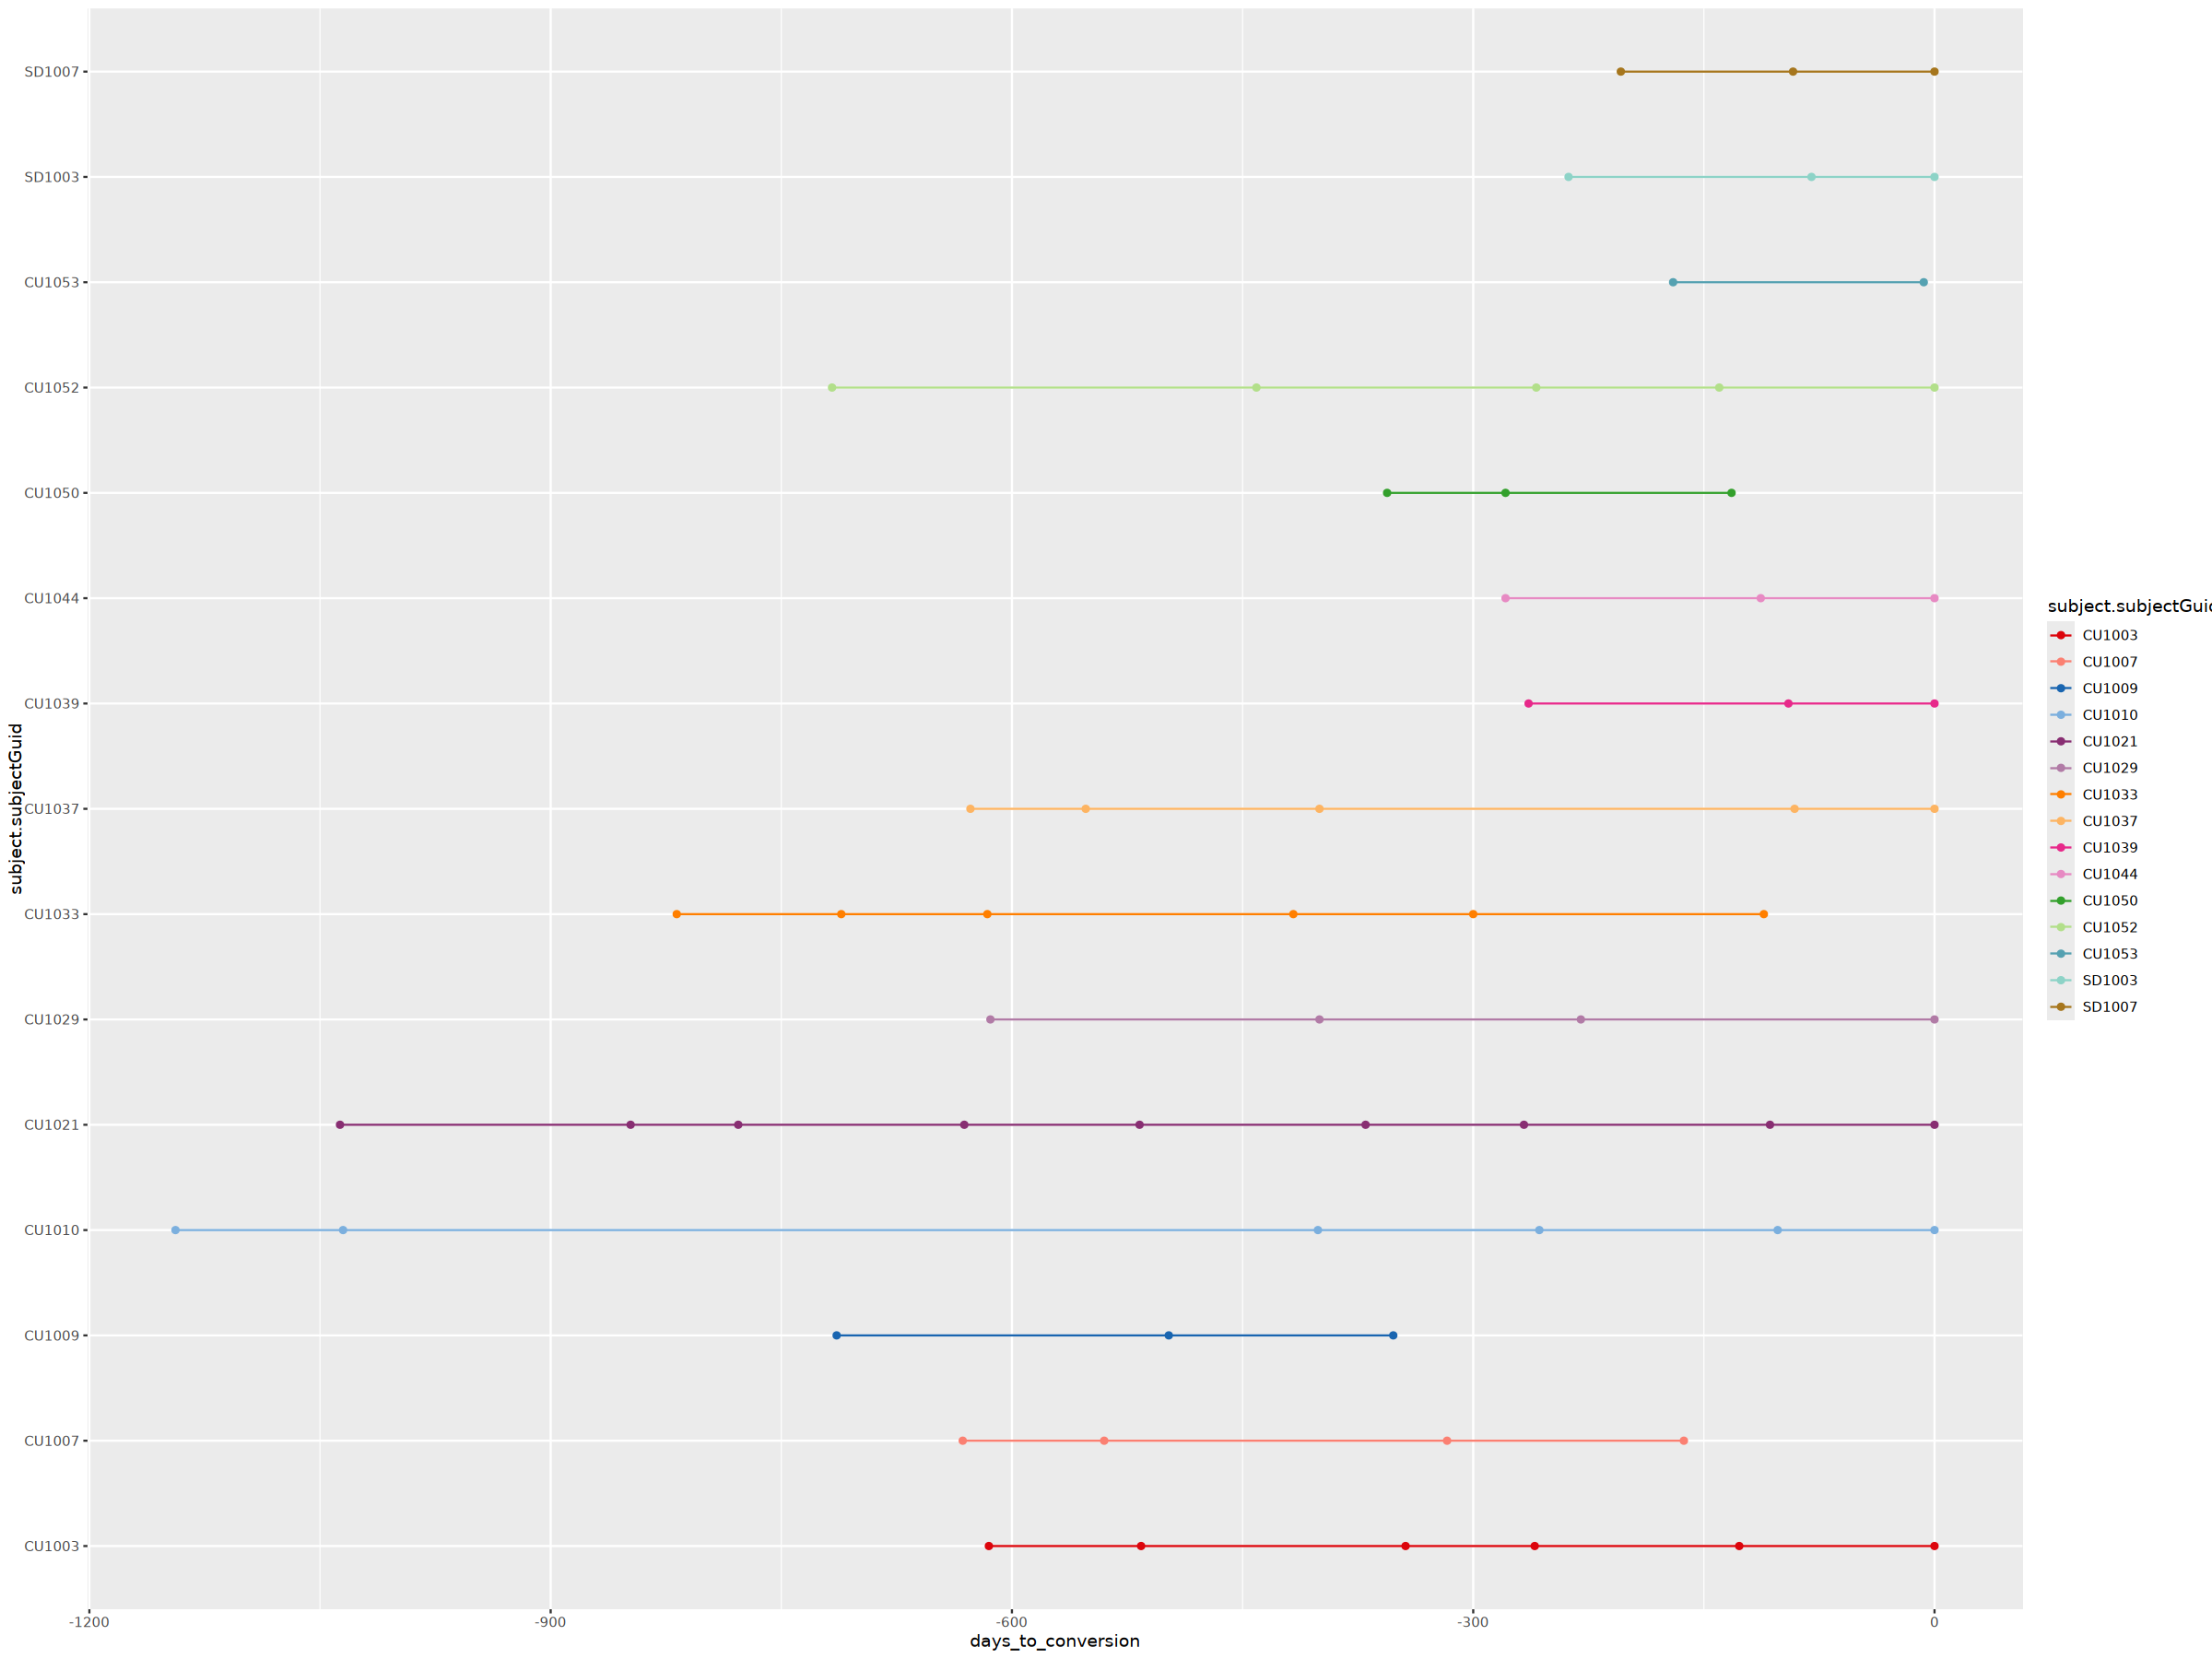

In [22]:
# plot the samples
ggplot(
  colData(aim3_pb[[celltype_test]]) %>% as_tibble(),
  aes(
    x = days_to_conversion, y = subject.subjectGuid,
    group = subject.subjectGuid, color = subject.subjectGuid
  )
) +
  geom_point() +
  geom_path() +
  scale_color_manual(values = cluster_colors)

ggsave(file.path(fig_path, paste0(proj_name, "_sample_selection.png")),
  width = 6, height = 6
)

In [23]:
# select metadata for paired comparisons
# select first pre timepoint
first_timepoint <- colData(aim3_pb[[celltype_test]]) %>%
  as_tibble() %>%
  group_by(subject.subjectGuid) %>%
  slice_min(days_to_conversion)
# select last pre conversion timepoint
# one
last_pre_timepoint <- colData(aim3_pb[[celltype_test]]) %>%
  as_tibble() %>%
  filter(Status_Long != "conversion" & days_to_conversion != -7) %>%
  group_by(subject.subjectGuid) %>%
  slice_max(days_to_conversion)
# select conversion timepoint
conv_timepoint <- colData(aim3_pb[[celltype_test]]) %>%
  as_tibble() %>%
  filter(Status_Long == "conversion" | days_to_conversion == -7)
# select samples that are paired
pair_sample <- bind_rows(last_pre_timepoint, conv_timepoint) %>% # bind_rows(first_timepoint)%>%
  distinct(sample.sampleKitGuid, .keep_all = TRUE) %>%
  select(
    subject.subjectGuid, sample.drawDate, sample.sampleKitGuid, file.batchID,
    sample.diseaseStatesRecordedAtVisit, Status_Long, days_to_conversion
  ) %>%
  arrange(subject.subjectGuid, days_to_conversion) %>%
  group_by(subject.subjectGuid) %>%
  mutate(pair_number = n()) %>%
  filter(pair_number >= 2) %>%
  mutate(status = if_else(sample.sampleKitGuid %in% conv_timepoint$sample.sampleKitGuid,
    "conversion", "pre_conv"
  ))

pair_kit <- pair_sample$sample.sampleKitGuid
pair_kit %>% length()

[1] 22

In [24]:
pair_sample %>% head()
pair_sample %>% nrow()

subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,file.batchID,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion,pair_number,status
<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
CU1003,2021-02-01,KT00493,B176,Rheumatoid arthritis,pre,-127,2,pre_conv
CU1003,2021-06-01,KT02135,B087,Rheumatoid arthritis,conversion,0,2,conversion
CU1010,2022-09-01,KT04474,B178,Rheumatoid arthritis,pre,-102,2,pre_conv
CU1010,2023-01-01,KT04108,B164,CCP3+ At Risk for RA,conversion,0,2,conversion
CU1021,2022-08-01,KT04105,B140,Rheumatoid arthritis,pre,-107,2,pre_conv
CU1021,2022-11-01,KT04462,B158,Rheumatoid arthritis,conversion,0,2,conversion


[1] 22

In [62]:
pair_sample %>% write_csv(file.path(output_path, paste0(proj_name, 'paired_samples_info.csv')))

In [25]:
# check average pre-conversion time
pair_sample %>%
  filter(status == "pre_conv") %>%
  pull(days_to_conversion) %>%
  summary()
pair_sample %>%
  filter(status == "pre_conv") %>%
  pull(days_to_conversion) %>%
  sd()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -230.0  -133.5  -107.0  -122.5   -93.5   -80.0 

[1] 44.01673

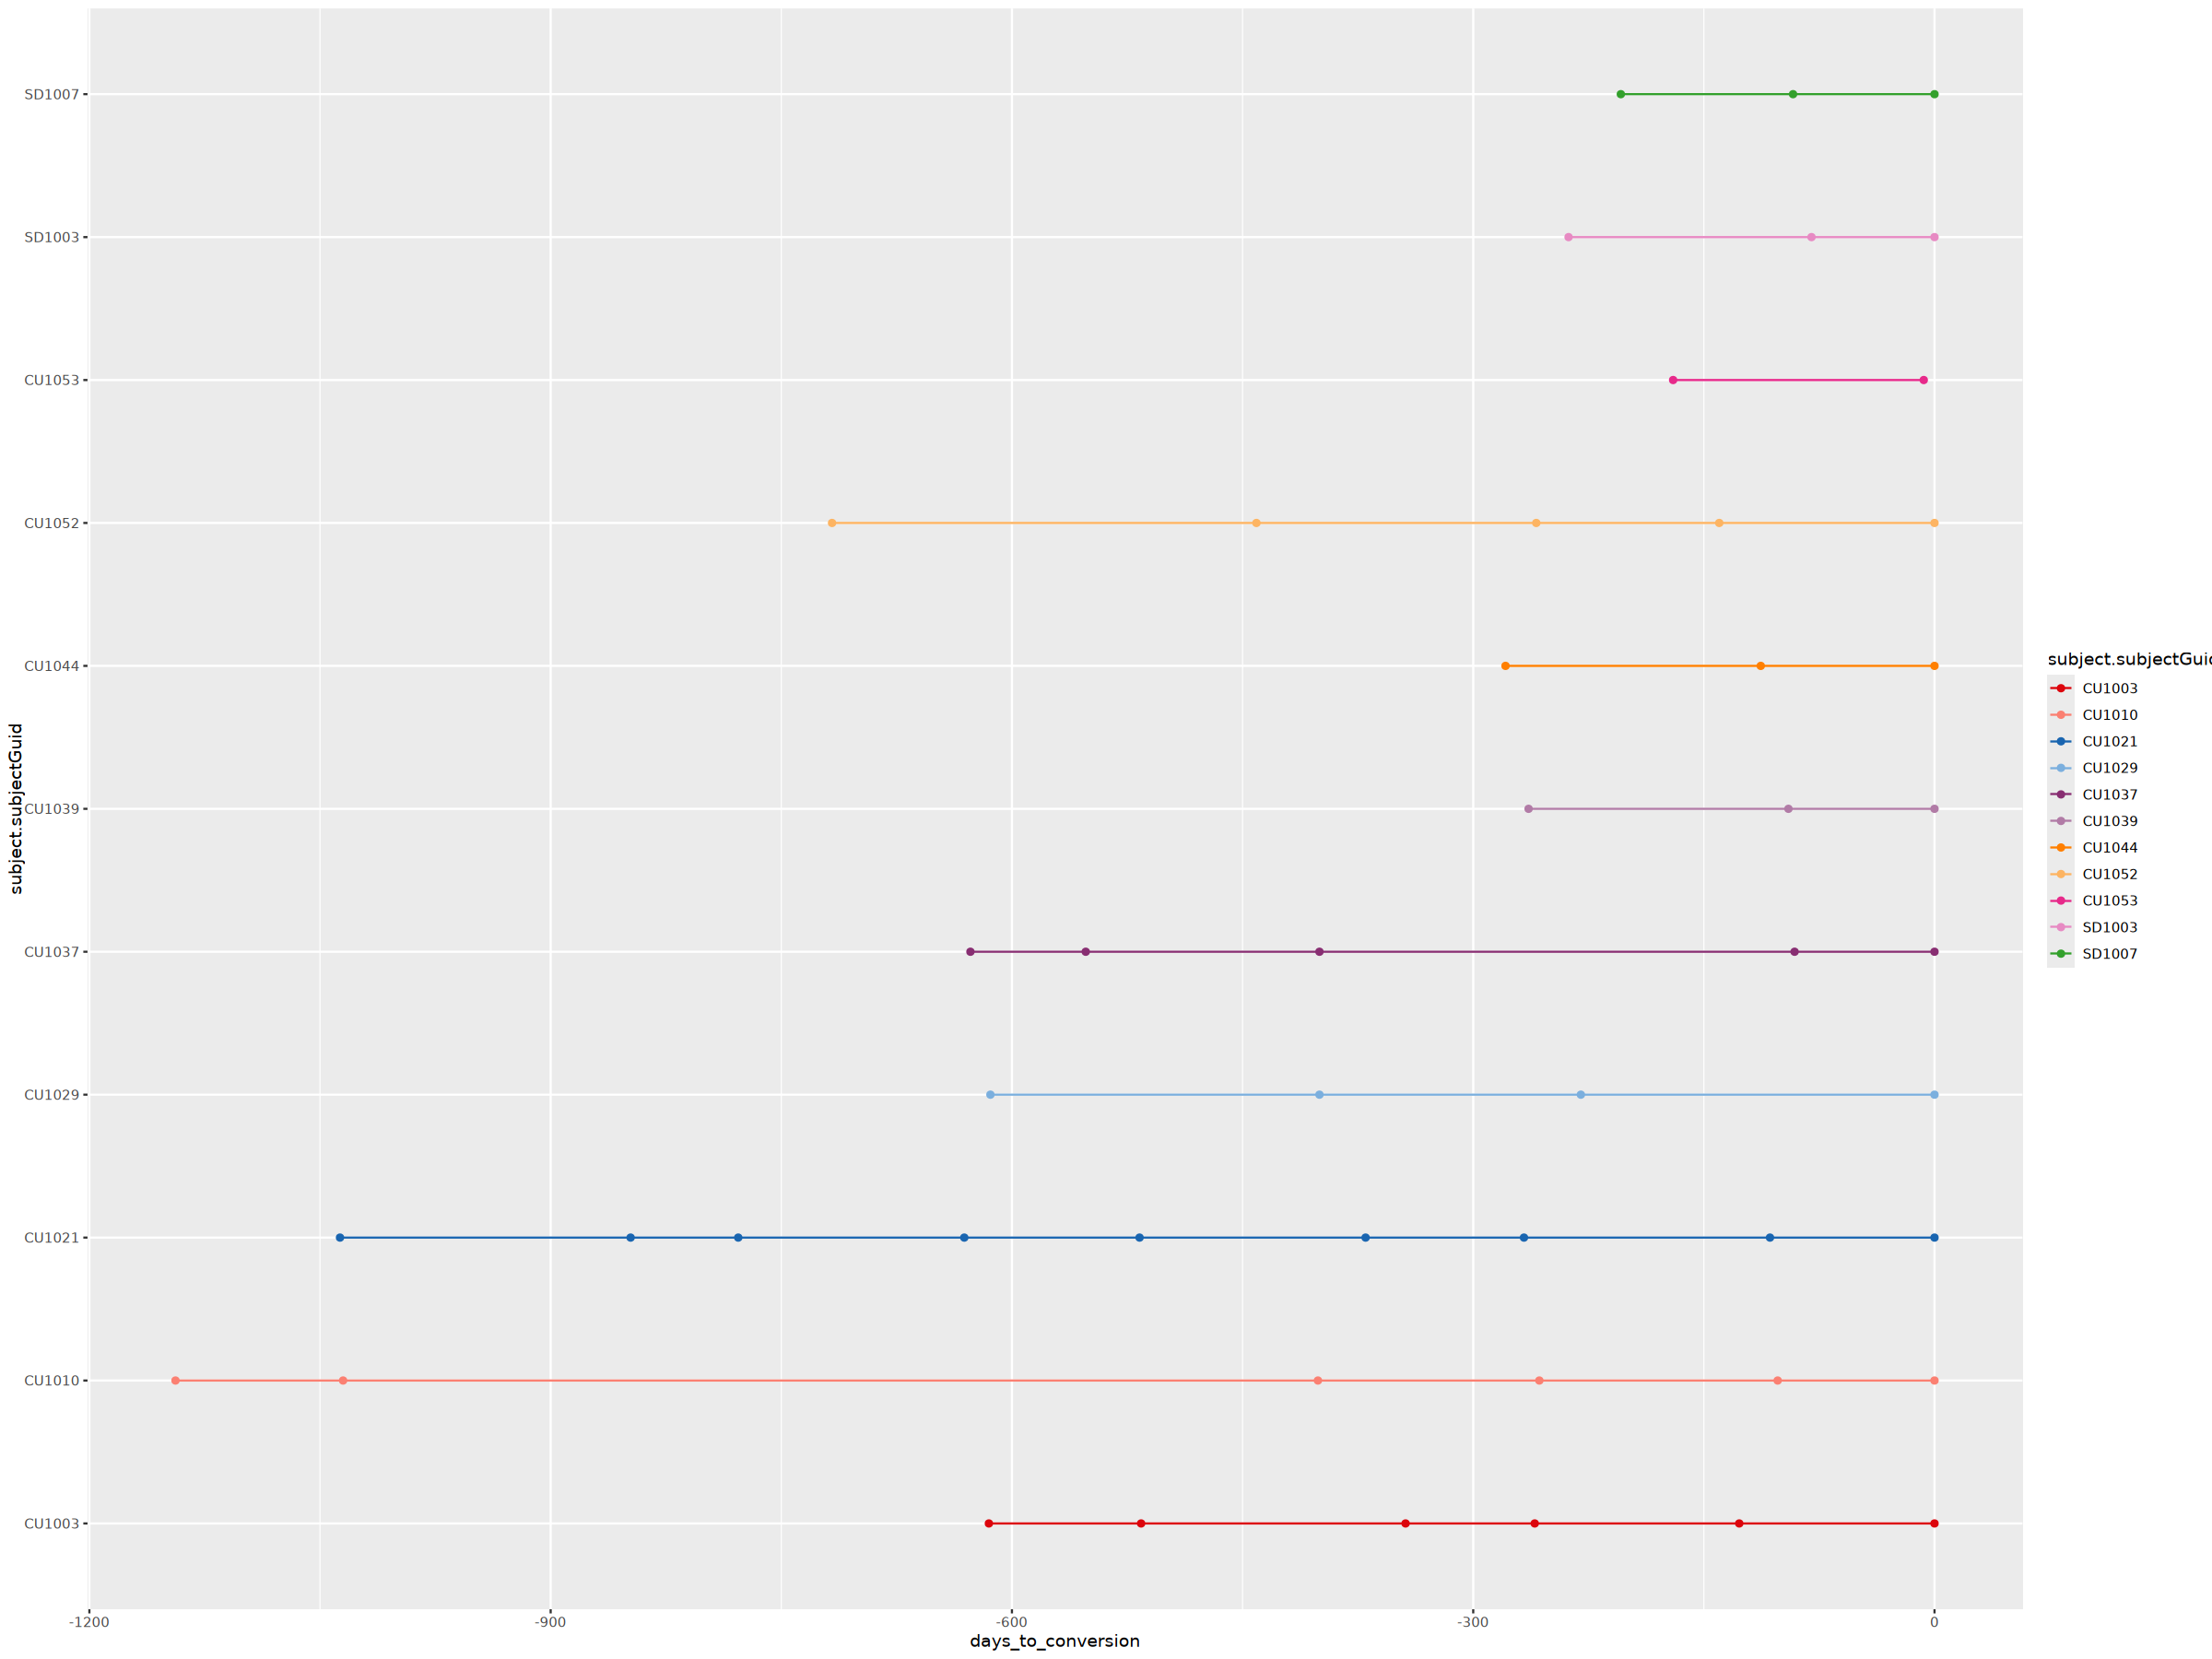

In [26]:
# plot the paried samples
ggplot(
  colData(aim3_pb[[celltype_test]]) %>% as_tibble() %>% filter(subject.subjectGuid %in% pair_sample$subject.subjectGuid),
  aes(
    x = days_to_conversion, y = subject.subjectGuid,
    group = subject.subjectGuid, color = subject.subjectGuid
  )
) +
  geom_point() +
  geom_line() +
  scale_color_manual(values = cluster_colors)

ggsave(file.path(fig_path, paste0(proj_name, "_pre_post_sample_selection.png")),
  width = 6, height = 6
)

In [27]:
pair_sample %>% head()
# get the kit id for the 11 conversion samples
conv_id <- pair_sample %>%
  filter(status == "conversion") %>%
  pull(sample.sampleKitGuid)

subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,file.batchID,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion,pair_number,status
<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
CU1003,2021-02-01,KT00493,B176,Rheumatoid arthritis,pre,-127,2,pre_conv
CU1003,2021-06-01,KT02135,B087,Rheumatoid arthritis,conversion,0,2,conversion
CU1010,2022-09-01,KT04474,B178,Rheumatoid arthritis,pre,-102,2,pre_conv
CU1010,2023-01-01,KT04108,B164,CCP3+ At Risk for RA,conversion,0,2,conversion
CU1021,2022-08-01,KT04105,B140,Rheumatoid arthritis,pre,-107,2,pre_conv
CU1021,2022-11-01,KT04462,B158,Rheumatoid arthritis,conversion,0,2,conversion


In [28]:
# create a new metadata for pair comparison
aim3_pb_pair_conv <- lapply(aim3_pb, function(pb) {
  pb_sub <- pb[, colData(pb)$sample.sampleKitGuid %in% pair_sample$sample.sampleKitGuid]
  colData(pb_sub)$status <- if_else(colData(pb_sub)$sample.sampleKitGuid %in% conv_id,
    "conversion", "pre_conv"
  )
  pb_sub$status <- factor(pb_sub$status, levels = c("pre_conv", "conversion"))
  # for each cell type only keep the paired samples
  pair_subj <- colData(pb_sub) %>%
    as_tibble() %>%
    group_by(subject.subjectGuid) %>%
    tally() %>%
    filter(n >= 2) %>%
    pull(subject.subjectGuid)
  pb_sub <- pb_sub[, colData(pb_sub)$subject.subjectGuid %in% pair_subj]
  return(pb_sub)
})

In [29]:
# check home many samples are present for each cell type
sample_numbers <- lapply(1:length(aim3_pb_pair_conv), function(i) {
  # calcualte how many paired samples
  pair_number <- colData(aim3_pb_pair_conv[[i]]) %>%
    as_tibble() %>%
    group_by(subject.subjectGuid) %>%
    tally() %>%
    filter(n >= 2)
  sample_number <- tibble("cell_type" = names(aim3_pb_pair_conv[i]), "pair_number" = nrow(pair_number))
  return(sample_number)
}) %>%
  rbindlist() %>%
  arrange(pair_number)
# set factor from small to large cell tyep
sample_numbers <- sample_numbers %>% mutate(cell_type = factor(cell_type, levels = unique(sample_numbers$cell_type)))

In [30]:
# get cell types which have enough sample number to run the model
# at least 3 samples for both
celltypes_large <- sample_numbers %>%
  filter(pair_number >= 3) %>%
  pull(cell_type) %>%
  as.character()
celltypes_large %>% length()
celltypes_drop <- sample_numbers %>%
  filter(!cell_type %in% celltypes_large) %>%
  pull(cell_type) %>%
  unique() %>%
  as.character()
# perform deg in these cell types
celltypes_large

[1] 63

[1] "Early memory B cell"                 
 [2] "Erythrocyte"                         
 [3] "SOX4+ Vd1 gdT"                       
 [4] "CM CD4 T cell_uk2"                   
 [5] "KLRF1- effector Vd1 gdT"             
 [6] "SOX4+ naive CD8 T cell"              
 [7] "CD8aa"                               
 [8] "GZMB- CD27+ EM CD4 T cell_uk1_CD8"   
 [9] "KLRF1+GZMB+_CD27-_EM_CD8_uk3"        
[10] "CD4 MAIT"                            
[11] "GZMB- CD27- EM CD4 T cell_uk1_CD8"   
[12] "ISG+ CD16 monocyte"                  
[13] "ISG+ CD56dim NK cell"                
[14] "KLRF1+ effector Vd1 gdT"             
[15] "Naive Vd1 gdT"                       
[16] "Plasma cell"                         
[17] "CD95 memory B cell"                  
[18] "IL1B+ CD14 monocyte"                 
[19] "ISG+ naive B cell"                   
[20] "KLRF1- GZMB+ CD27- memory CD4 T cell"
[21] "Platelet"                            
[22] "Proliferating T cell"                
[23] "CD27- effector B cell"               
[24] "Intermediate monocyte"               
[25] "KLRB1+ memory CD4 Treg"              
[26] "Proliferating NK cell"               
[27] "SOX4+ naive CD4 T cell"              
[28] "Type 2 polarized memory B cell"      
[29] "Adaptive NK cell"                    
[30] "CD27+ effector B cell"               
[31] "CD8 MAIT"                            
[32] "GZMK- CD27+ EM CD8 T cell"           
[33] "GZMK+ CD27+ EM CD8 T cell_uk1_gdt"   
[34] "ISG+ naive CD4 T cell"               
[35] "KLRF1+ GZMB+ CD27- EM CD8 T cell"    
[36] "C1Q+ CD16 monocyte"                  
[37] "CD14+ cDC2"                          
[38] "CD56bright NK cell"                  
[39] "CM CD4 T cell"                       
[40] "CM CD4 T cell_uk1_CD8"               
[41] "CM CD8 T cell"                       
[42] "Core CD14 monocyte"                  
[43] "Core CD16 monocyte"                  
[44] "Core memory B cell"                  
[45] "Core naive B cell"                   
[46] "Core naive CD4 T cell"               
[47] "Core naive CD8 T cell"               
[48] "DN T cell"                           
[49] "GZMB- CD27- EM CD4 T cell"           
[50] "GZMB- CD27+ EM CD4 T cell"           
[51] "GZMB+ Vd2 gdT"                       
[52] "GZMK- CD56dim NK cell"               
[53] "GZMK+ CD27+ EM CD8 T cell"           
[54] "GZMK+ CD56dim NK cell"               
[55] "GZMK+ Vd2 gdT"                       
[56] "HLA-DRhi cDC2"                       
[57] "ISG+ CD14 monocyte"                  
[58] "ISG+ memory CD4 T cell"              
[59] "KLRF1- GZMB+ CD27- EM CD8 T cell"    
[60] "Memory CD4 Treg"                     
[61] "Naive CD4 Treg"                      
[62] "pDC"                                 
[63] "Transitional B cell"

In [31]:
# check metadata
colData(aim3_pb_pair_conv[[celltype_test]]) %>%
  as_tibble() %>%
  select(status, Status_Long, days_to_conversion, subject.subjectGuid, file.batchID) %>%
  arrange(subject.subjectGuid) %>%
  head()

status,Status_Long,days_to_conversion,subject.subjectGuid,file.batchID
<fct>,<chr>,<dbl>,<chr>,<chr>
pre_conv,pre,-127,CU1003,B176
conversion,conversion,0,CU1003,B087
conversion,conversion,0,CU1010,B164
pre_conv,pre,-102,CU1010,B178
pre_conv,pre,-107,CU1021,B140
conversion,conversion,0,CU1021,B158


## run deseq2

In [39]:
# run deseq to do paired analysis
aim3_pair_conv_deseq <- RunDeseq_list(aim3_pb_pair_conv[celltypes_large], formula = "~ subject.subjectGuid + status")

run Deseq2 for cell type Early memory B cell

converting counts to integer mode

Warning message in DESeqDataSet(pb, design = as.formula(formula)):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type Erythrocyte

converting counts to integer mode

Warning message in DESeqDataSet(pb, design = as.formula(formula)):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type SOX4+ Vd1 gdT

converting counts to integer mode

Warning message in DESeqDataSet(pb, design = as.formula(formula)):
“some variables in design formula are characters, converting to factors”
estimating size fac

In [74]:
aim3_pair_conv_deseq %>% length()

[1] 63

In [75]:
# get result
aim3_conv_deseq_res <- lapply(aim3_pair_conv_deseq, results)

In [76]:
# extract the result as a table
aim3_conv_deseq_res_table <- lapply(names(aim3_conv_deseq_res), function(i) {
  res_tb <- aim3_conv_deseq_res[[i]] %>%
    as_tibble(rownames = "gene") %>%
    mutate(cell_type = i)
  return(res_tb)
}) %>% rbindlist()

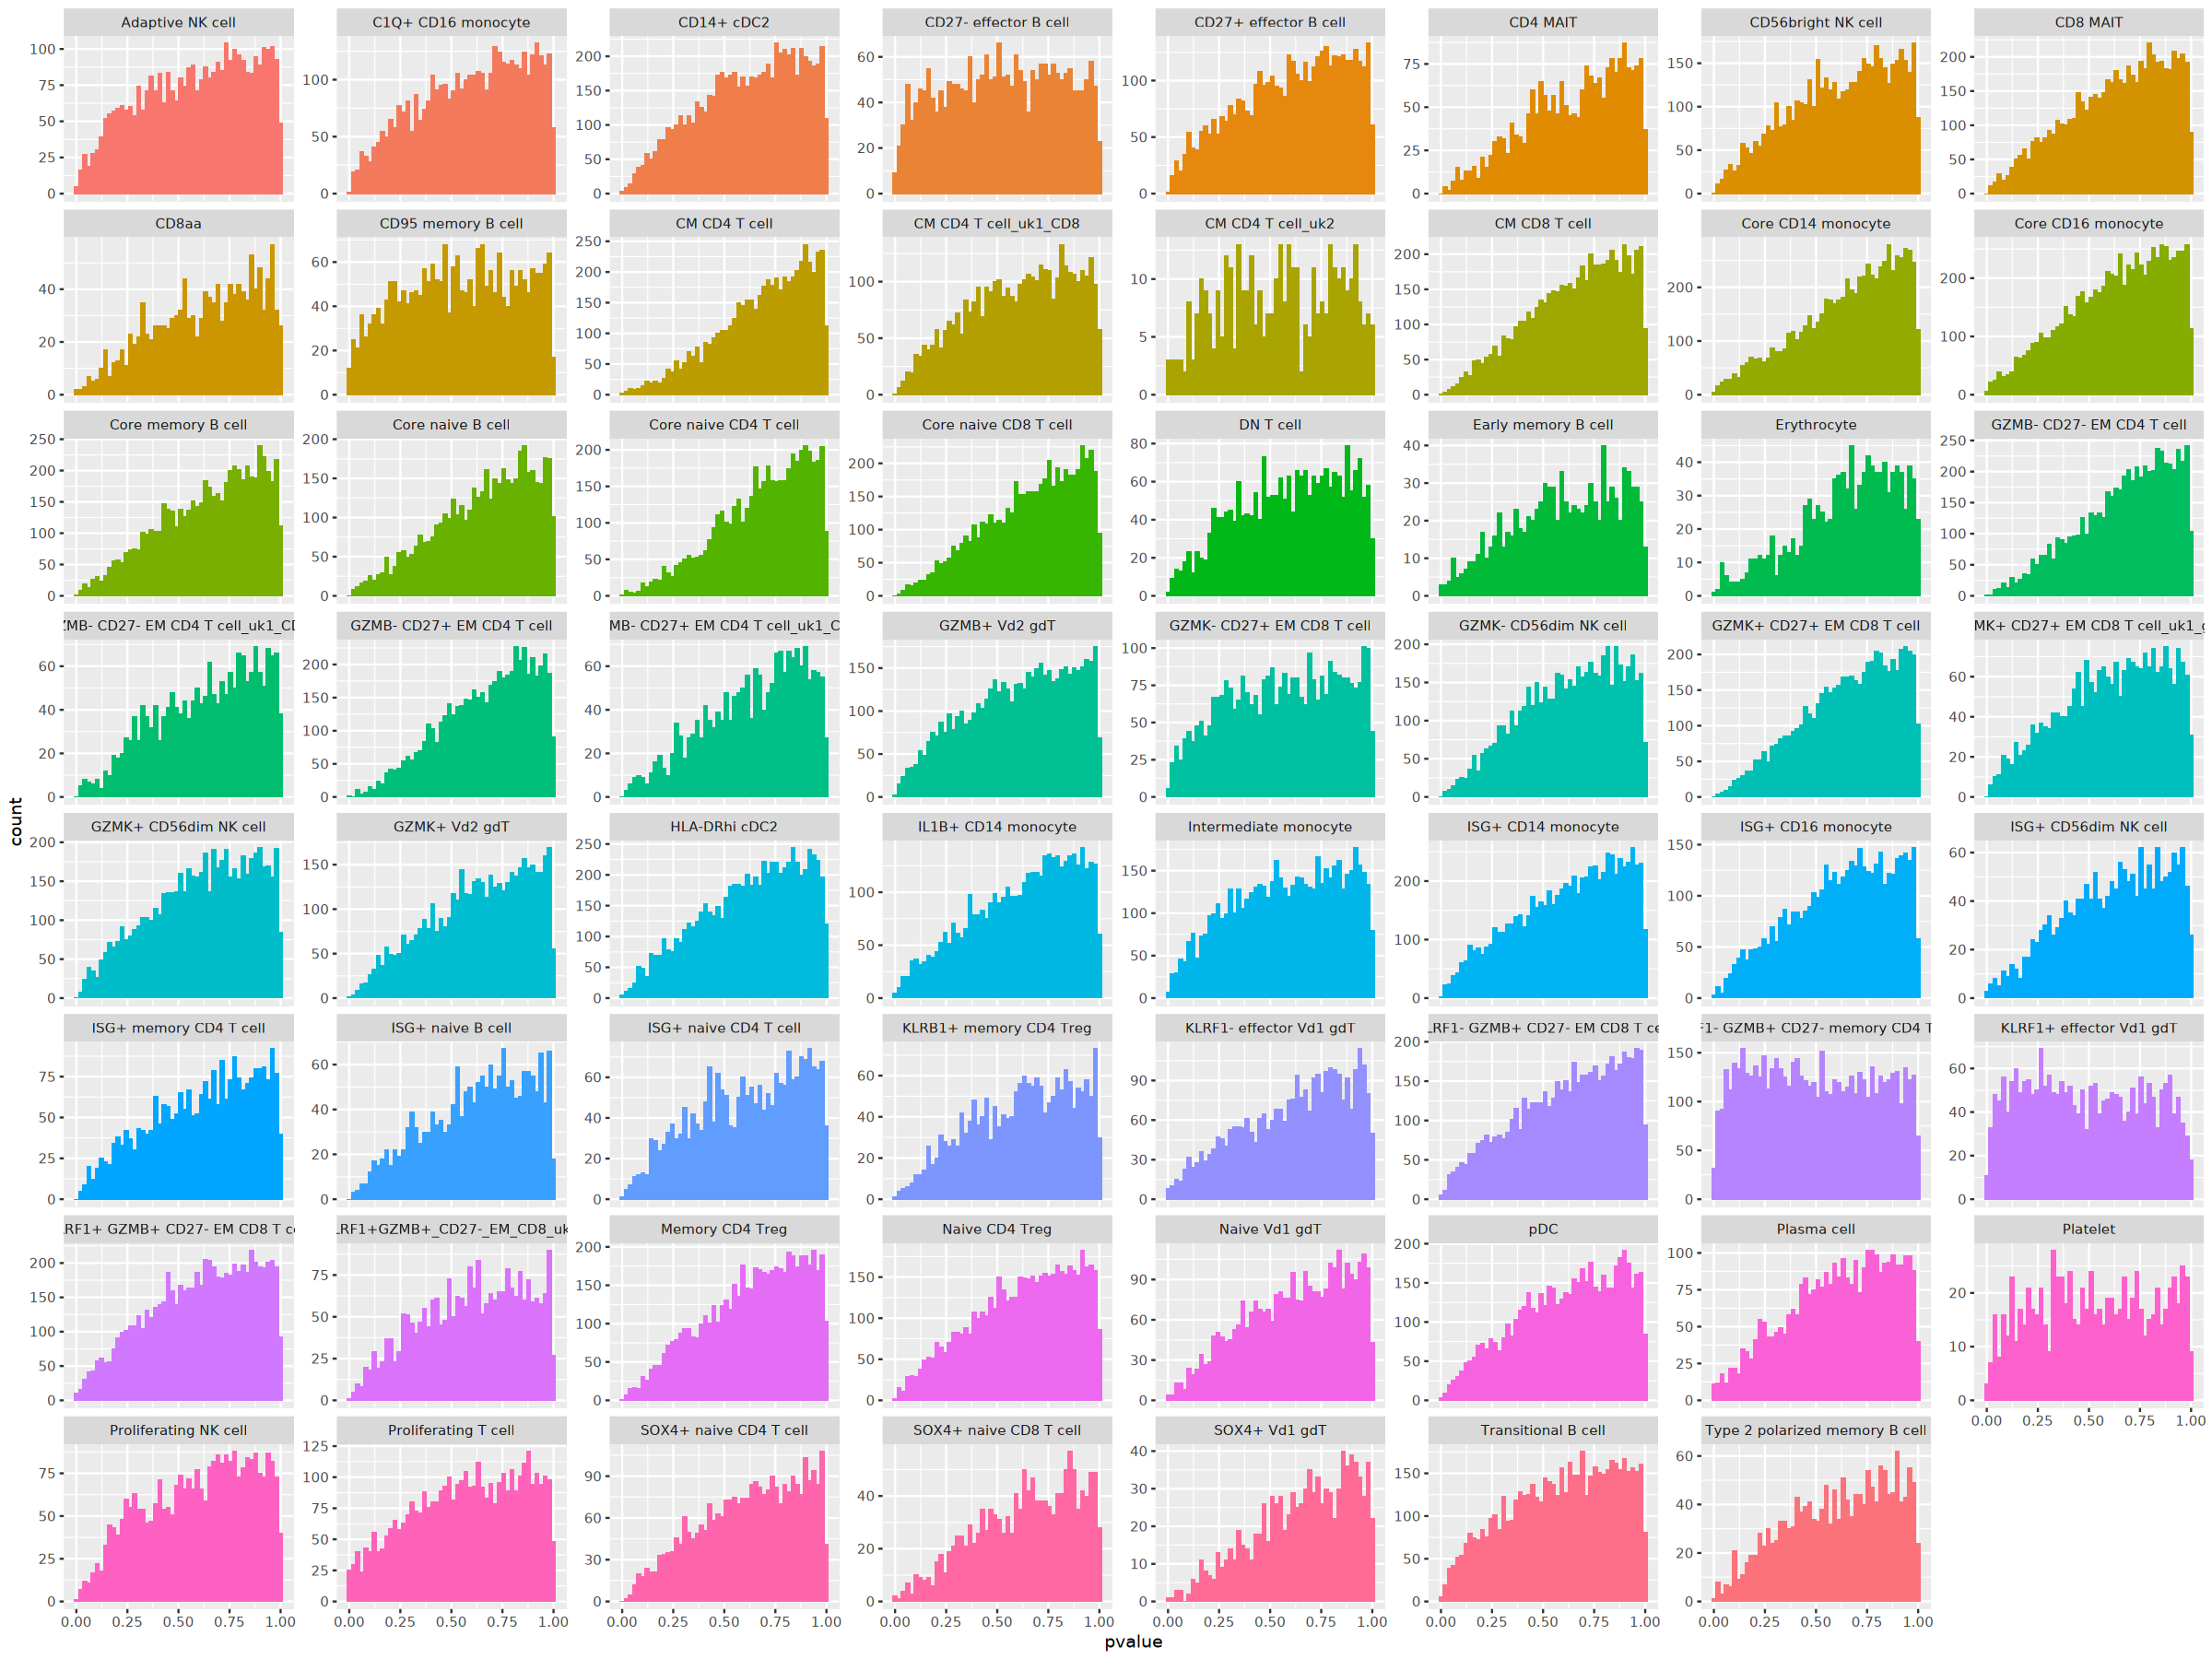

In [77]:
# plot the p values
options(repr.plot.width = 20, repr.plot.height = 15)
aim3_conv_deseq_res_table %>% ggplot(aes(x = pvalue, fill = cell_type)) +
  geom_histogram(bins = 50) +
  facet_wrap(vars(cell_type), scales = "free_y") +
  theme(legend.position = "none")

ggsave(
  file.path(fig_path, paste0(
    proj_name,
    "_pre_post_conv_p_values_distribution.png"
  )),
  width = 16, height = 12
)

In [82]:
aim3_conv_deseq_res_table %>% head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AC004687.1,11.48758,0.37825878,0.6626774,0.57080379,0.56813265,0.9990187,Early memory B cell
ACAP1,11.04703,0.11014722,0.6846475,0.16088164,0.87218662,0.9990187,Early memory B cell
ACAP2,12.65534,-0.06282015,0.6544081,-0.09599537,0.92352425,0.9990187,Early memory B cell
ACBD3,13.85478,-0.31478474,0.6246507,-0.50393719,0.61430551,0.9990187,Early memory B cell
ACTB,218.07549,0.40856905,0.2242837,1.82166207,0.06850628,0.9990187,Early memory B cell
ACTG1,59.71726,0.74585442,0.3467215,2.15116318,0.03146332,0.9990187,Early memory B cell


In [83]:
# calculate the qvalues
aim3_conv_deseq_res_qvalue <- aim3_conv_deseq_res_table %>%
  group_by(cell_type) %>%
  group_modify(~ calQvalue(.x, p_col = "pvalue")) %>%
  rstatix::add_significance(
    p.col = "q_values", output.col = "sig",
    cutpoints = c(0, 0.05, 0.2, 1),
    symbols = c("*", "<0.2", "ns")
  )

In [85]:
aim3_conv_deseq_res_qvalue %>%
  filter(q_values < 0.2) %>%
  arrange(desc(log2FoldChange))

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Plasma cell,ASPM,7.76631,3.2336867,0.7580363,4.265873,1.991222e-05,6.521251e-02,6.521251e-02,<0.2
ISG+ CD16 monocyte,CXCL10,19.32169,2.8217265,0.6024406,4.683825,2.815699e-06,1.254675e-02,1.254675e-02,*
Proliferating T cell,LMNA,13.75468,1.9251791,0.4677081,4.116197,3.851743e-05,5.027809e-02,5.027809e-02,<0.2
CD95 memory B cell,LGALS1,58.52746,1.4444447,0.2447936,5.900665,3.620402e-09,4.257592e-06,4.257592e-06,*
CD95 memory B cell,JCHAIN,275.60640,1.4062320,0.2070190,6.792766,1.100034e-11,2.587281e-08,2.587281e-08,*
CD95 memory B cell,IGLC2,823.31193,1.2893950,0.3570356,3.611391,3.045592e-04,1.790808e-01,1.790808e-01,<0.2
CD95 memory B cell,IGHA1,117.14997,0.8593125,0.2106638,4.079070,4.521629e-05,3.544957e-02,3.544957e-02,*
Core CD16 monocyte,TNF,42.47443,0.7854057,0.1733217,4.531490,5.856902e-06,4.477016e-02,4.477016e-02,*
Proliferating T cell,RPS10,163.91538,0.5860876,0.1629330,3.597108,3.217754e-04,1.794448e-01,1.794448e-01,<0.2


In [87]:
aim3_conv_deseq_res_qvalue %>% write_csv(file.path(output_path, paste0(proj_name, "deseq2_deg_list.csv")))

### Output table S26 DEG results

In [6]:
# load deg list
aim3_conv_deseq_res_qvalue <- read_csv(file.path(output_path, paste0(proj_name, "deseq2_deg_list.csv")))
aim3_conv_deseq_res_qvalue %>% head()

Rows: 253007 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): cell_type, gene, sig
dbl (7): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Adaptive NK cell,AAK1,39.186588,-0.09885216,0.1937081,-0.5103149,0.6098308,0.9993347,0.9993347,ns
Adaptive NK cell,AASDHPPT,9.253967,-0.12763481,0.2533369,-0.5038146,0.6143917,0.9993347,0.9993347,ns
Adaptive NK cell,AATF,13.256907,0.15333509,0.2267103,0.6763483,0.4988196,0.9993347,0.9993347,ns
Adaptive NK cell,ABCB1,8.869858,0.04081630,0.3133005,0.1302784,0.8963462,0.9993347,0.9993347,ns
Adaptive NK cell,ABCE1,6.951014,0.07337815,0.2855077,0.2570094,0.7971715,0.9993347,0.9993347,ns
Adaptive NK cell,ABCF1,23.302221,0.03256938,0.2081183,0.1564945,0.8756432,0.9993347,0.9993347,ns


In [8]:
# output DEG list
aim3_pair_degs <- aim3_conv_deseq_res_qvalue %>%
  select(-padj) %>%
  rename("q_values" = "qvalue") %>%
  arrange(qvalue)
aim3_pair_degs %>% head()
aim3_pair_degs %>% write_csv(file.path(output_path, "Sup_table_AIM3_paired_conversion_deseq2_deg_list.csv"))

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,qvalue,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD95 memory B cell,JCHAIN,275.60640,1.4062320,0.2070190,6.792766,1.100034e-11,2.587281e-08,*
CD95 memory B cell,LGALS1,58.52746,1.4444447,0.2447936,5.900665,3.620402e-09,4.257592e-06,*
Proliferating T cell,NKG7,203.24157,-1.0134948,0.1760689,-5.756239,8.600870e-09,3.368101e-05,*
Proliferating T cell,GZMB,40.08333,-1.4919887,0.2999942,-4.973392,6.579138e-07,1.288195e-03,*
ISG+ CD16 monocyte,CXCL10,19.32169,2.8217265,0.6024406,4.683825,2.815699e-06,1.254675e-02,*
CD95 memory B cell,IGHA1,117.14997,0.8593125,0.2106638,4.079070,4.521629e-05,3.544957e-02,*


In [88]:
cd16_mon_aim3_pair <- aim3_conv_deseq_res_qvalue %>% filter(cell_type == "Core CD16 monocyte")
cd16_mon_aim3_pair %>%
  arrange(pvalue) %>%
  head(10)

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Core CD16 monocyte,TNF,42.47443,0.7854057,0.17332172,4.531490,5.856902e-06,0.04477016,0.04477016,*
Core CD16 monocyte,ZNRF2,47.68343,0.3962710,0.14145074,2.801477,5.086931e-03,0.99923672,0.99923672,ns
Core CD16 monocyte,APOBEC3A,476.68082,0.2502486,0.09479045,2.640020,8.290122e-03,0.99923672,0.99923672,ns
Core CD16 monocyte,GID4,15.99603,-0.5759044,0.21935902,-2.625396,8.654814e-03,0.99923672,0.99923672,ns
Core CD16 monocyte,IL1B,25.57612,0.6472275,0.24883071,2.601076,9.293196e-03,0.99923672,0.99923672,ns
Core CD16 monocyte,BTG2,272.39643,0.3255120,0.12543109,2.595146,9.455069e-03,0.99923672,0.99923672,ns
Core CD16 monocyte,MAFG,19.20516,0.5246507,0.20960100,2.503093,1.231133e-02,0.99923672,0.99923672,ns
Core CD16 monocyte,AC020911.2,18.13186,-0.6702259,0.27486273,-2.438402,1.475235e-02,0.99923672,0.99923672,ns
Core CD16 monocyte,CSRNP1,22.56965,0.4992177,0.20487421,2.436703,1.482183e-02,0.99923672,0.99923672,ns


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


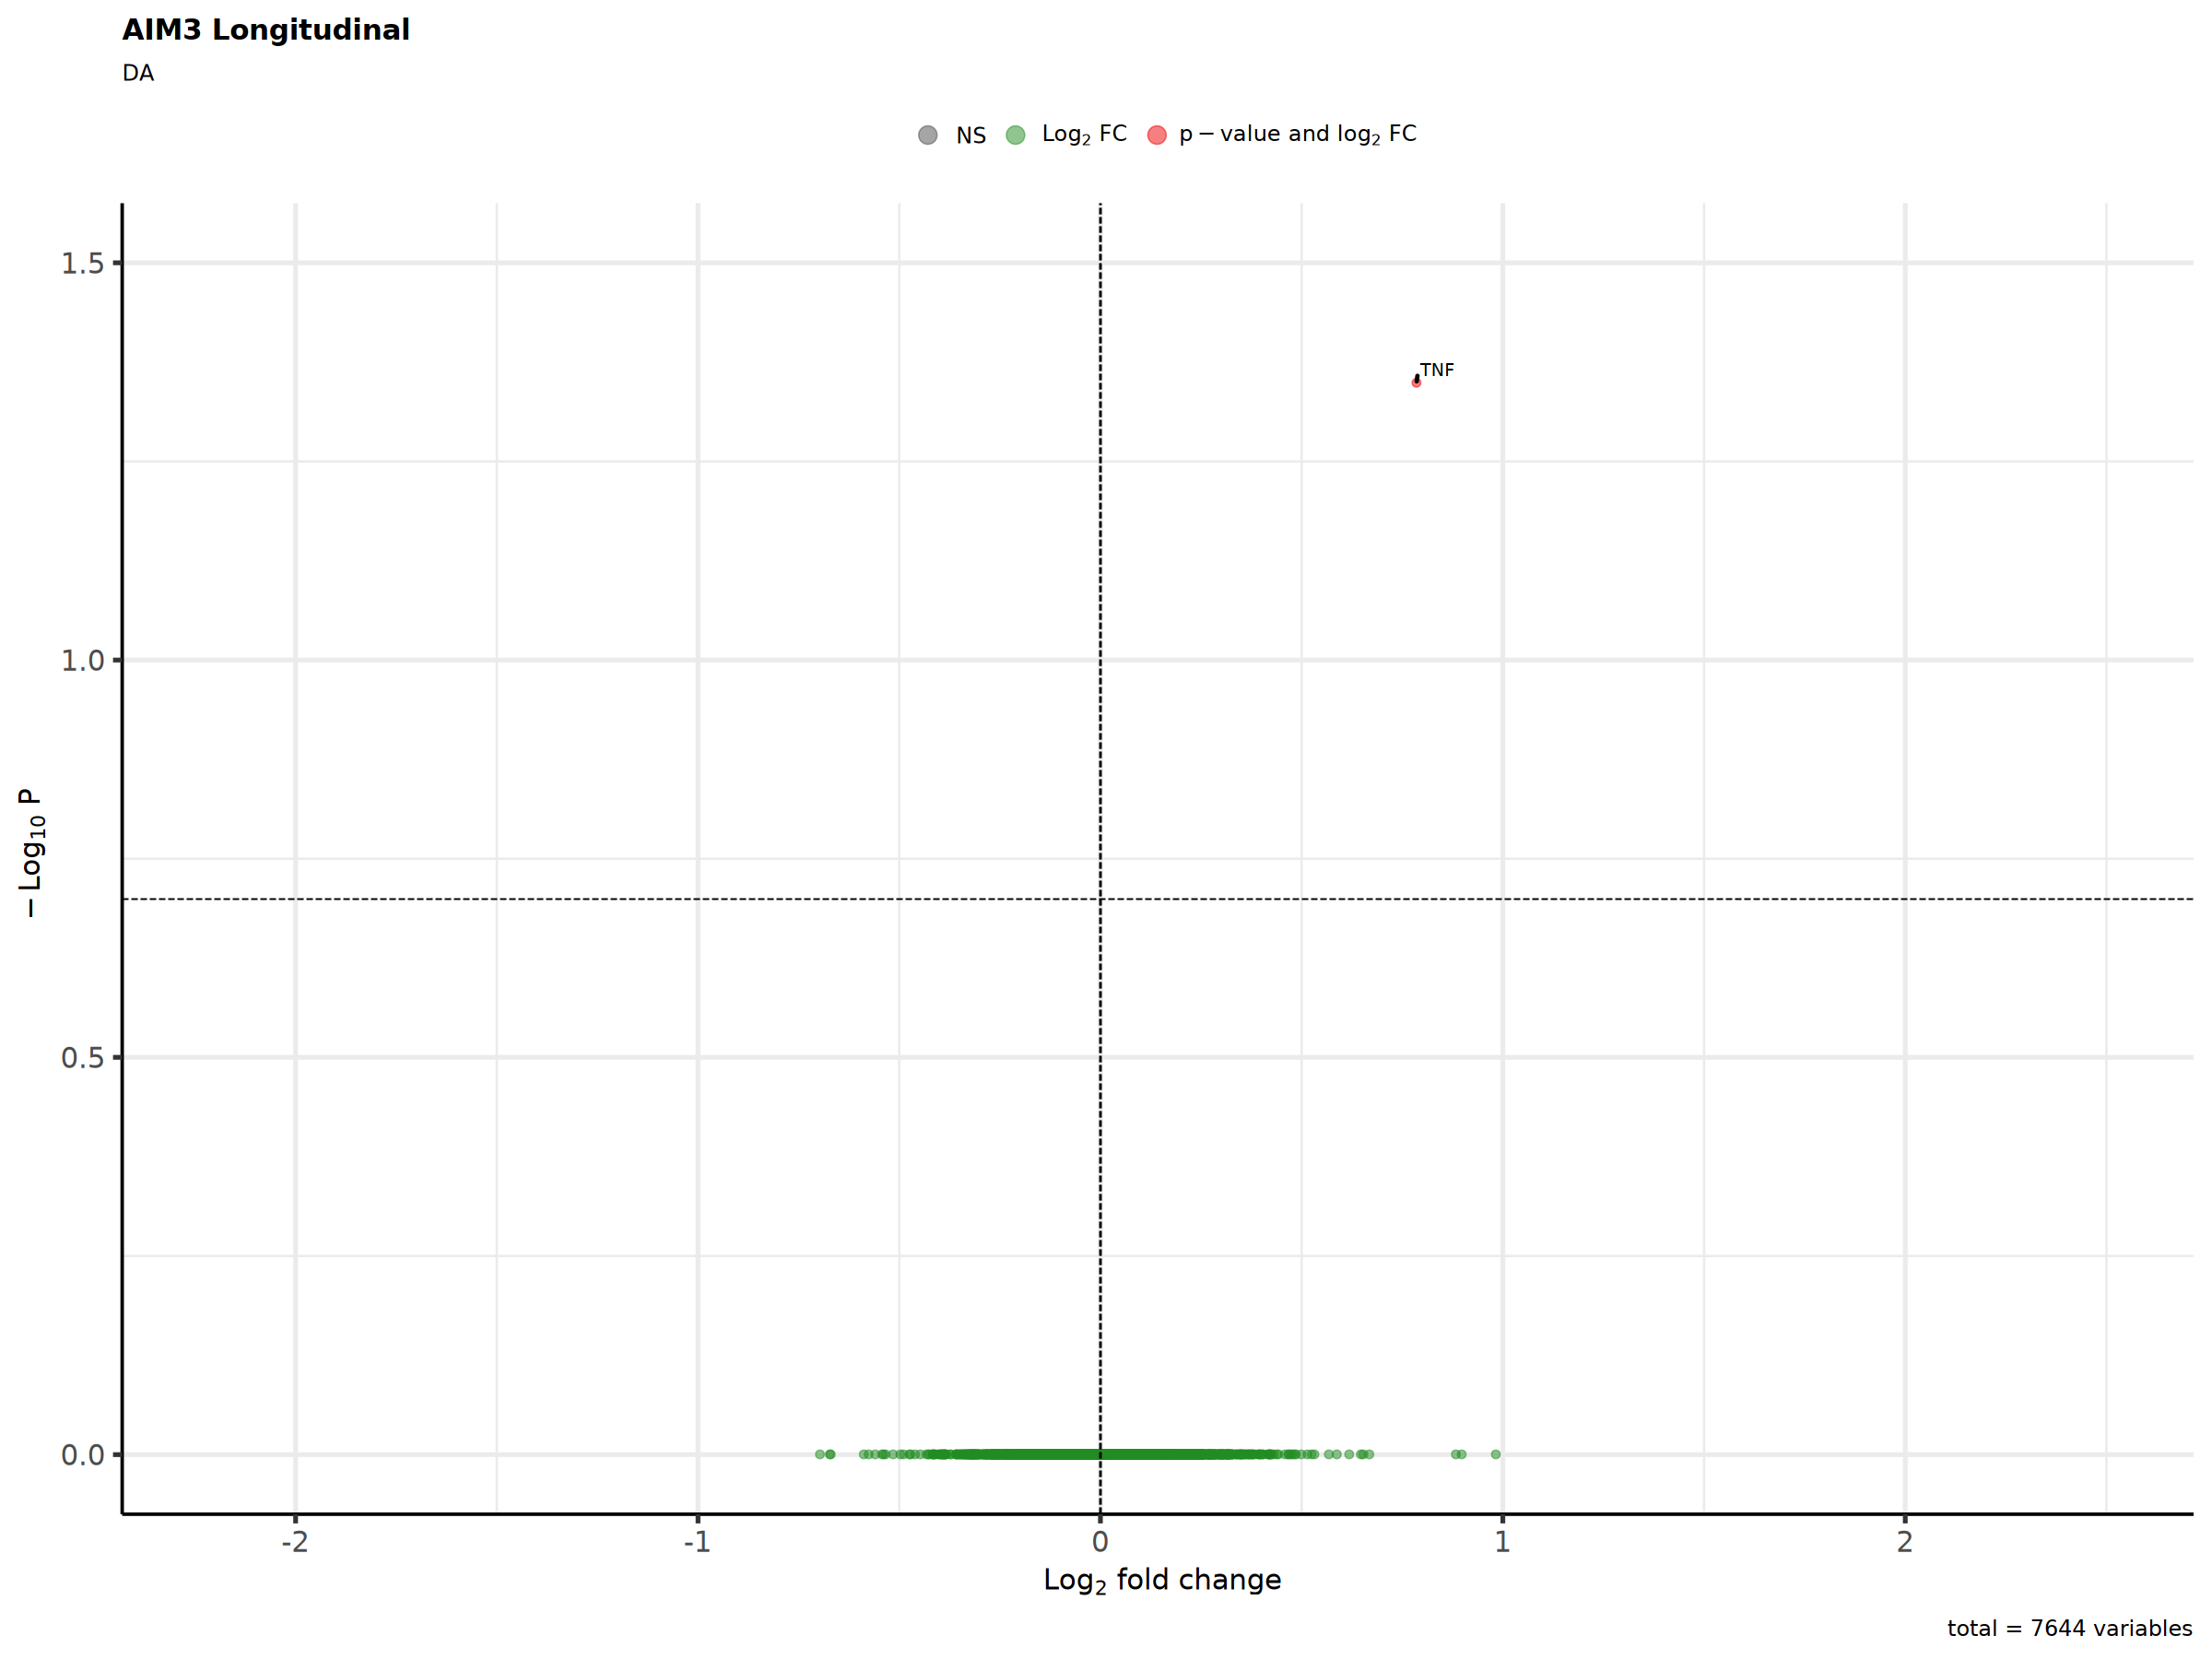

In [89]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(cd16_mon_aim3_pair,
  title = "AIM3 Longitudinal", subtitle = "DA",
  lab = cd16_mon_aim3_pair$gene,
  x = "log2FoldChange",
  y = "q_values",
  pCutoff = 0.2,
  FCcutoff = 0.0002,
  pointSize = 2.0, drawConnectors = TRUE,
  widthConnectors = 1.0,
  colConnectors = "black",
  arrowheads = FALSE,
  labSize = 4.0
) + ylim(0, 1.5)
p1
# ggsave(file.path(da_fig, paste0('AIM3_DA_valcano_plot.png')),
#        width=8, height=6)

# plot the deg gene expression

In [43]:
pair_sample%>% head()

subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,file.batchID,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion,pair_number,status
<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
CU1003,2021-02-01,KT00493,B176,Rheumatoid arthritis,pre,-127,2,pre_conv
CU1003,2021-06-01,KT02135,B087,Rheumatoid arthritis,conversion,0,2,conversion
CU1010,2022-09-01,KT04474,B178,Rheumatoid arthritis,pre,-102,2,pre_conv
CU1010,2023-01-01,KT04108,B164,CCP3+ At Risk for RA,conversion,0,2,conversion
CU1021,2022-08-01,KT04105,B140,Rheumatoid arthritis,pre,-107,2,pre_conv
CU1021,2022-11-01,KT04462,B158,Rheumatoid arthritis,conversion,0,2,conversion


In [44]:
# load the input deseq2 normalized data to run the model
aim3_pb_deseq <- readRDS(file.path(data_path, "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__deseq2_norm_counts_list.rds"))

In [45]:
# load deg at conversion
aim3_conv_deg <- fread("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired/ALTRA_AIM3_scRNA_Pseudobulk_paired_deseq2_deg_list.csv")
aim3_conv_deg_sig <- aim3_conv_deg %>% filter(q_values < 0.05 | (cell_type == "IL1B+ CD14 monocyte" & gene == "TNF"))
aim3_conv_deg_sig

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD95 memory B cell,IGHA1,117.14997,0.8593125,0.2106638,4.079070,4.521629e-05,3.544957e-02,3.544957e-02,*
CD95 memory B cell,JCHAIN,275.60640,1.4062320,0.2070190,6.792766,1.100034e-11,2.587281e-08,2.587281e-08,*
CD95 memory B cell,LGALS1,58.52746,1.4444447,0.2447936,5.900665,3.620402e-09,4.257592e-06,4.257592e-06,*
Core CD16 monocyte,TNF,42.47443,0.7854057,0.1733217,4.531490,5.856902e-06,4.477016e-02,4.477016e-02,*
IL1B+ CD14 monocyte,TNF,19.43039,0.9117826,0.7762203,1.174644,2.401372e-01,9.997020e-01,9.997020e-01,ns
ISG+ CD16 monocyte,CXCL10,19.32169,2.8217265,0.6024406,4.683825,2.815699e-06,1.254675e-02,1.254675e-02,*
Proliferating T cell,GZMB,40.08333,-1.4919887,0.2999942,-4.973392,6.579138e-07,1.288195e-03,1.288195e-03,*
Proliferating T cell,NKG7,203.24157,-1.0134948,0.1760689,-5.756239,8.600870e-09,3.368101e-05,3.368101e-05,*


In [49]:
# get gene expression longitudinal for the deg changes at conversion
gex_lg <- GetExprsSE(deg_list = aim3_conv_deg_sig, SE_list = aim3_pb_deseq, assay = "vst") %>%
  mutate(Sex = subject.biologicalSex)
# get gene expression at pre post conversion points for the deg changes at conversion
gex_conv <- gex_lg %>%
  filter(sample.sampleKitGuid %in% pair_sample$sample.sampleKitGuid) %>%
  select(-status) %>%
  left_join(select(ungroup(pair_sample), c(sample.sampleKitGuid, status)), by = "sample.sampleKitGuid") %>%
  mutate(status = factor(recode(status, "pre_conv" = "Pre-clinical RA", "conversion" = "Clinical RA"),
    levels = c("Pre-clinical RA", "Clinical RA")
  ))
gex_conv %>% head()

index,batch_id,hto_barcode,hto_category,pbmc_sample_id,pool_id,sample.sampleKitGuid,cohort.cohortGuid,subject.subjectGuid,subject.biologicalSex,⋯,bmi_conv,file.batchID,psbulk_n_cells,psbulk_counts,cell_type,gene,normalized_counts,celltype_gene,Sex,status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<fct>
KT00103_CD95 memory B cell,B046,ATTGACCCGCGTTAG,singlet,PB00103-01,B046-P2,KT00103,SD1,SD1003,Female,⋯,25.65487,B046,26,255496,CD95 memory B cell,IGHA1,7.035490,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00105_CD95 memory B cell,B070,CAGTAGTCACGGTCA,singlet,PB00105-01,B070-P2,KT00105,SD1,SD1007,Female,⋯,26.02500,B070,37,366580,CD95 memory B cell,IGHA1,6.389852,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00109_CD95 memory B cell,B046,CAGTAGTCACGGTCA,singlet,PB00109-01,B046-P2,KT00109,SD1,SD1003,Female,⋯,25.65487,B046,17,204983,CD95 memory B cell,IGHA1,7.361373,CD95 memory B cell: IGHA1,Female,Clinical RA
KT00493_CD95 memory B cell,B176,CTCCTCTGCAATTAC,singlet,PB00493-02,B176-P1,KT00493,CU1,CU1003,Female,⋯,23.14306,B176,12,117753,CD95 memory B cell,IGHA1,6.617786,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00500_CD95 memory B cell,B176,AGTAAGTTCAGCGTA,singlet,PB00500-02,B176-P1,KT00500,CU1,CU1029,Female,⋯,28.67547,B176,14,142158,CD95 memory B cell,IGHA1,6.467002,CD95 memory B cell: IGHA1,Female,Pre-clinical RA
KT00790_CD95 memory B cell,B088,CAGTAGTCACGGTCA,singlet,PB00790-01,B088-P1,KT00790,SD1,SD1007,Female,⋯,26.02500,B088,17,169552,CD95 memory B cell,IGHA1,6.149014,CD95 memory B cell: IGHA1,Female,Clinical RA


### Output table S26 gene expression data

In [50]:
# get the normalized gene counts
pair_deg_exprs <- gex_conv %>%
  select(
    sample.sampleKitGuid, subject.subjectGuid,
    Sex, status, cell_type, gene, celltype_gene, normalized_counts
  ) %>%
  filter(celltype_gene %in% c(
    "Core CD16 monocyte: TNF", "ISG+ CD16 monocyte: CXCL10",
    "CD95 memory B cell: IGHA1", "CD95 memory B cell: JCHAIN", "IL1B+ CD14 monocyte: TNF"
  )) %>%
  arrange(celltype_gene, subject.subjectGuid, status) %>%
  group_by(celltype_gene, subject.subjectGuid) %>%
  mutate(pair_samples = n_distinct(sample.sampleKitGuid)) %>%
  filter(pair_samples == 2) %>%
  ungroup() %>%
  select(-pair_samples)

In [51]:
# convert the hise subject id to ids used in the manuscript
subj_id <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/ALTRA_SubjectID_lookup.csv", show_col_types = FALSE) %>%
  rename("sample_id" = "sample.sampleKitGuid", "subject_id" = "Subject ID")
pair_deg_exprs <- pair_deg_exprs %>%
  left_join(subj_id, by = "sample.sampleKitGuid") %>%
  select(-subject.subjectGuid)

In [52]:
pair_deg_exprs %>% head()

sample.sampleKitGuid,Sex,status,cell_type,gene,celltype_gene,normalized_counts,Subject ID
<chr>,<fct>,<fct>,<chr>,<chr>,<chr>,<dbl>,<chr>
KT00493,Female,Pre-clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,6.617786,ARI35
KT02135,Female,Clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,7.381532,ARI35
KT00500,Female,Pre-clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,6.467002,ARI37
KT02844,Female,Clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,7.343488,ARI37
KT03930,Female,Pre-clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,6.581400,ARI40
KT04085,Female,Clinical RA,CD95 memory B cell,IGHA1,CD95 memory B cell: IGHA1,7.526937,ARI40


In [40]:
pair_deg_exprs %>%
  write_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/paired/ALTRA_AIM3_scRNA_Pseudobulk_paired_deseq2_deg_exprs.csv")

In [77]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] ggthemes_5.1.0              ggpubr_0.6.1               
 [3] scater_1.34.1               knitr_1.50                 
 [5] DESeq2_1.46.0               data.table_1.17.6          
 [7] scran_1.34.0                scuttle_1.16.0             
 [9] SingleCellExperiment_1.28.0 SummarizedExperiment